In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, pzflow
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from pzflow import Flow
from pzflow.bijectors import Chain, ShiftBounds, RollingSplineCoupling, StandardScaler
from pzflow.distributions import Uniform, Normal, CentBeta, CentBeta13

from msi.utils import input_output, plotting, mcmc
from msfm.utils import prior, parameters

23-07-21 03:33:59    scales.py INF   Setting up healpy to run on 256 CPUs 


### settings

In [3]:
# bumping up the precision from float32 to float64 seems to be beneficial
from jax.config import config
config.update("jax_enable_x64", True)

# network predictions

### choose a run

In [4]:
base_dir = "/pscratch/sd/a/athomsen/run_files/v3"
# base_dir = "/Users/arne/data/DESY3/models/v3/"

In [5]:
# # clustering only
# model_dir = "2023-05-30_01-48-23_resnet_vanilla"
# n_steps = 50000
# params = ["Om", "s8", "bg", "n_bg"]

In [6]:
# lensing only
model_dir = "2023-05-29_09-55-49_resnet_vanilla"
n_steps = 50000
params = ["Om", "s8", "Aia", "n_Aia"]

In [7]:
# # combined probes
# model_dir = "2023-05-30_10-56-53_resnet_vanilla"
# n_steps = 10000
# params = ["Om", "s8", "Aia", "n_Aia", "bg", "n_bg"]

### general

In [8]:
fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos, grid_sobol = input_output.load_preds(base_dir, model_dir, n_steps)

out_dir = os.path.join(base_dir, model_dir)

23-07-21 03:33:59 input_output INF   Array shapes:
 
23-07-21 03:33:59 input_output INF   fidu_train_preds =   (750, 4) 
23-07-21 03:33:59 input_output INF   fidu_vali_preds =    (50, 4) 
23-07-21 03:33:59 input_output INF   grid_preds =         (2499, 16, 4) 
23-07-21 03:33:59 input_output INF   grid_cosmos =        (2499, 4) 
23-07-21 03:33:59 input_output INF   grid_sobol =         (2499, 4) 


In [9]:
assert fidu_train_preds.shape[1] == fidu_vali_preds.shape[1] == grid_preds.shape[2]

n_params = len(params)
n_cosmos = grid_preds.shape[0]
n_examples = grid_preds.shape[1]
n_summaries = grid_preds.shape[2]
summary_labels = [f"summary_{i}" for i in range(n_summaries)]

In [10]:
train_test_split = 0.8

# construct the dataframe
df_list = []
for i in range(n_examples):

    df_sobol = pd.DataFrame(grid_sobol, columns=["sobol"])

    df_cosmo = pd.DataFrame()
    for j, param in enumerate(params):
        df_cosmo[param] = grid_cosmos[:,j]

    df_summary = pd.DataFrame()
    for j in range(n_summaries):
        df_summary[f"summary_{j}"] = grid_preds[:,i,j]

    df_list.append(df_sobol.join([df_cosmo, df_summary]))

# combine along the example axis
df_total = pd.concat(df_list, axis=0)
df_total = df_total.sample(frac=1.0)

# train/test split
df_train = df_total[: int(train_test_split * len(df_total))]
df_val = df_total[int(train_test_split* len(df_total)) :]

### observation

In [11]:
obs_pred = np.median(fidu_vali_preds, axis=0)
obs_df = pd.DataFrame([obs_pred], columns=[f"summary_{i}" for i in range(n_summaries)])

# normalizing flow

## learn the likelihood $p(s | \theta)$

In [12]:
label = f"{n_steps}_flow_likelihood"

Training 300 epochs 
Loss:
(0) 12.1595  12.1455
(1) -1.5724  -1.5684
(16) -7.2678  -7.1664
(31) -7.6874  -7.5546
(46) -7.5010  -7.3515
(61) -7.8563  -7.6642
(76) -7.8588  -7.6609
(91) -7.6636  -7.4619
(106) -7.8368  -7.6095
(121) -7.8881  -7.6160
(136) -7.7795  -7.4952
(151) -7.8460  -7.5517
(166) -8.0512  -7.7330
(181) -7.9106  -7.6155
(196) -8.0029  -7.6537
(211) -8.0249  -7.6949
(226) -8.0873  -7.7310
(241) -8.0047  -7.6416
(256) -7.9941  -7.6506
(271) -7.9459  -7.5838
(286) -8.0900  -7.6481
(300) -8.1055  -7.6673


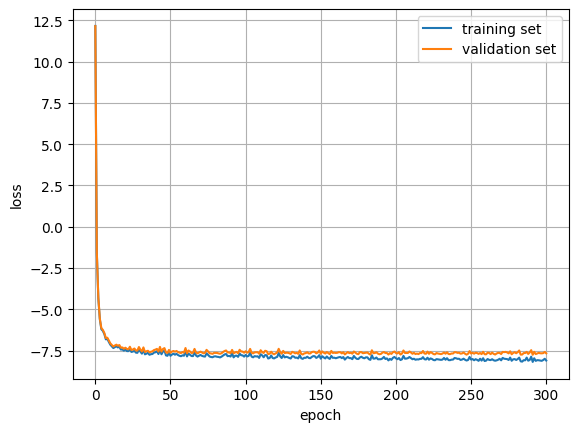

In [13]:
latent = CentBeta13(input_dim=n_summaries, B=5)
bijector = Chain(
    ShiftBounds(jnp.array(df_total[summary_labels].min(axis=0)), jnp.array(df_total[summary_labels].max(axis=0)), B=4),
    RollingSplineCoupling(n_summaries, B=5, n_conditions=n_params, hidden_dim=128),
)

flow = Flow(
    data_columns=summary_labels, 
    conditional_columns=params, 
    latent=latent,
    bijector=bijector,
)

# train
loss_train, loss_val = flow.train(df_train, df_val, verbose=True, epochs=300)
# loss_train = flow.train(df_total, verbose=True, epochs=100)

# plot
fig, ax = plt.subplots()
ax.plot(loss_train, label="training set")
ax.plot(loss_val, label="validation set")
ax.set(xlabel="epoch", ylabel="loss")
ax.legend()
ax.grid(True)

## density estimation checks

In [14]:
# sample from the flow
n_samples_per_cosmo = 1000
df_cosmo = pd.DataFrame(grid_cosmos, columns=params)
pred_samples = flow.sample(n_samples_per_cosmo, conditions=df_cosmo)

pred_samples_array = pred_samples.to_numpy().reshape(n_cosmos, n_samples_per_cosmo, n_summaries + n_params)
pred_samples_array = pred_samples_array[:,:,:4]

[Text(0, 0.5, 'probability density')]

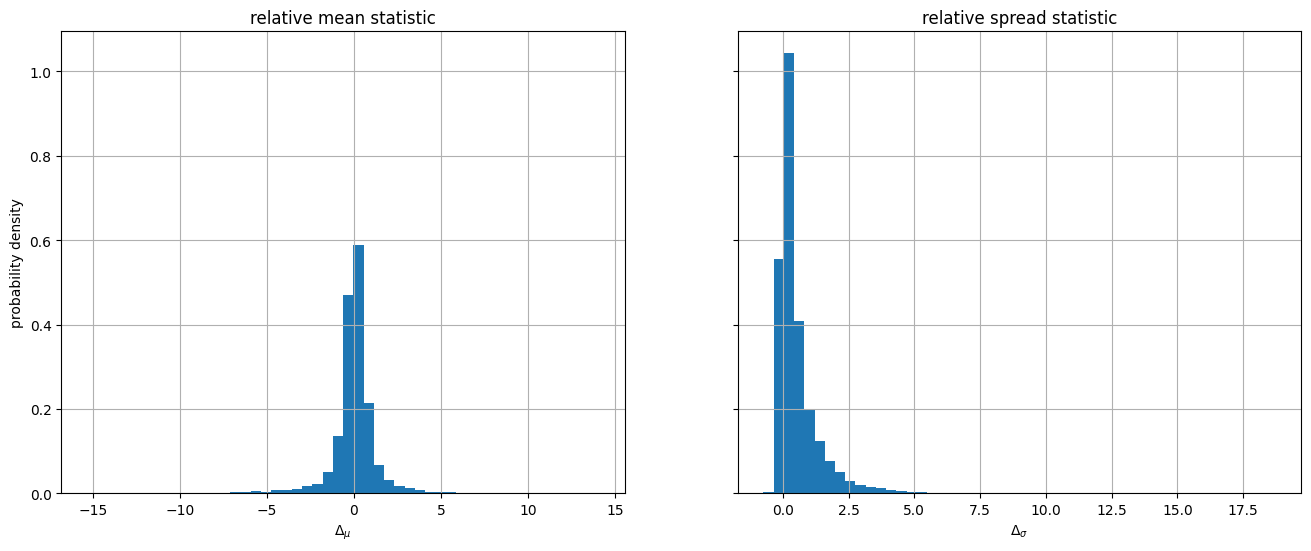

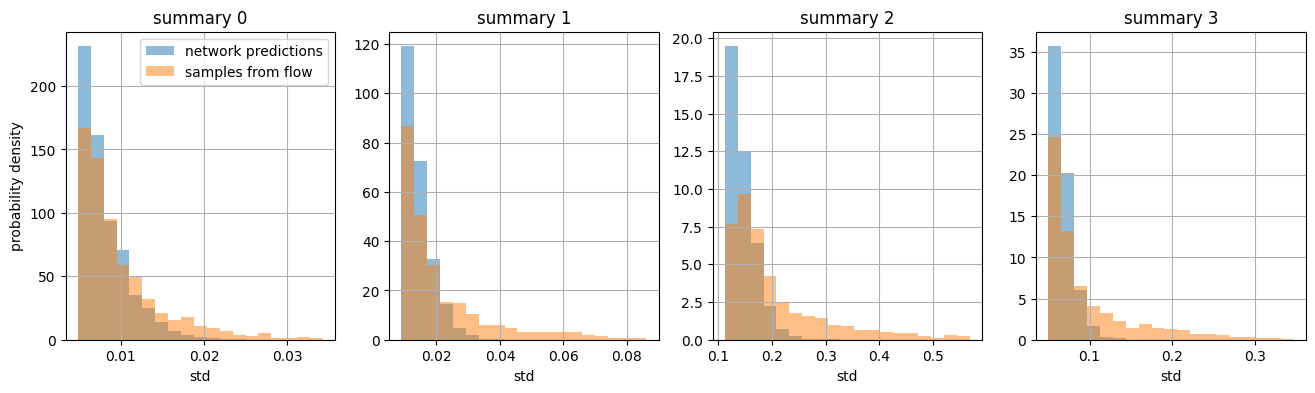

In [15]:
# network predictions
mean_preds = np.mean(grid_preds, axis=1)
std_preds = np.std(grid_preds, axis=1, ddof=1)

# flow samples
mean_samples = pred_samples.groupby(params, sort=False).mean().to_numpy()
std_samples = pred_samples.groupby(params, sort=False).std(ddof=1).to_numpy()

assert mean_preds.shape == std_preds.shape == mean_samples.shape == std_samples.shape

# test statistics, these should be tightly centered around zero
Delta_mu = (mean_samples - mean_preds)/std_preds
Delta_sigma = (std_samples - std_preds)/std_preds

Delta_mu = Delta_mu.ravel()
Delta_sigma = Delta_sigma.ravel()

# plot
fig, ax = plt.subplots(ncols=2, figsize=(16,6), sharey=True)

ax[0].hist(Delta_mu, bins=50, density=True)
ax[0].set(title="relative mean statistic", xlabel=r"$\Delta_\mu$", ylabel="probability density")
ax[0].grid(True)

ax[1].hist(Delta_sigma, bins=50, density=True)
ax[1].set(title="relative spread statistic", xlabel=r"$\Delta_\sigma$")
ax[1].grid(True)


fig, ax = plt.subplots(figsize=(16,4), ncols=n_summaries)

bin_mins = np.quantile(std_samples, 0.01, axis=0)
bin_maxs = np.quantile(std_samples, 0.99, axis=0)
bins = np.linspace(bin_mins, bin_maxs, 20)

for i in range(n_summaries):
    ax[i].hist(std_preds[:,i], bins=bins[:,i], label="network predictions", density=True, alpha=0.5)
    ax[i].hist(std_samples[:,i], bins=bins[:,i], label="samples from flow", density=True, alpha=0.5)

    ax[i].set(title=f"summary {i}", xlabel="std")
    ax[i].grid(True)

ax[0].legend()
ax[0].set(ylabel="probability density")

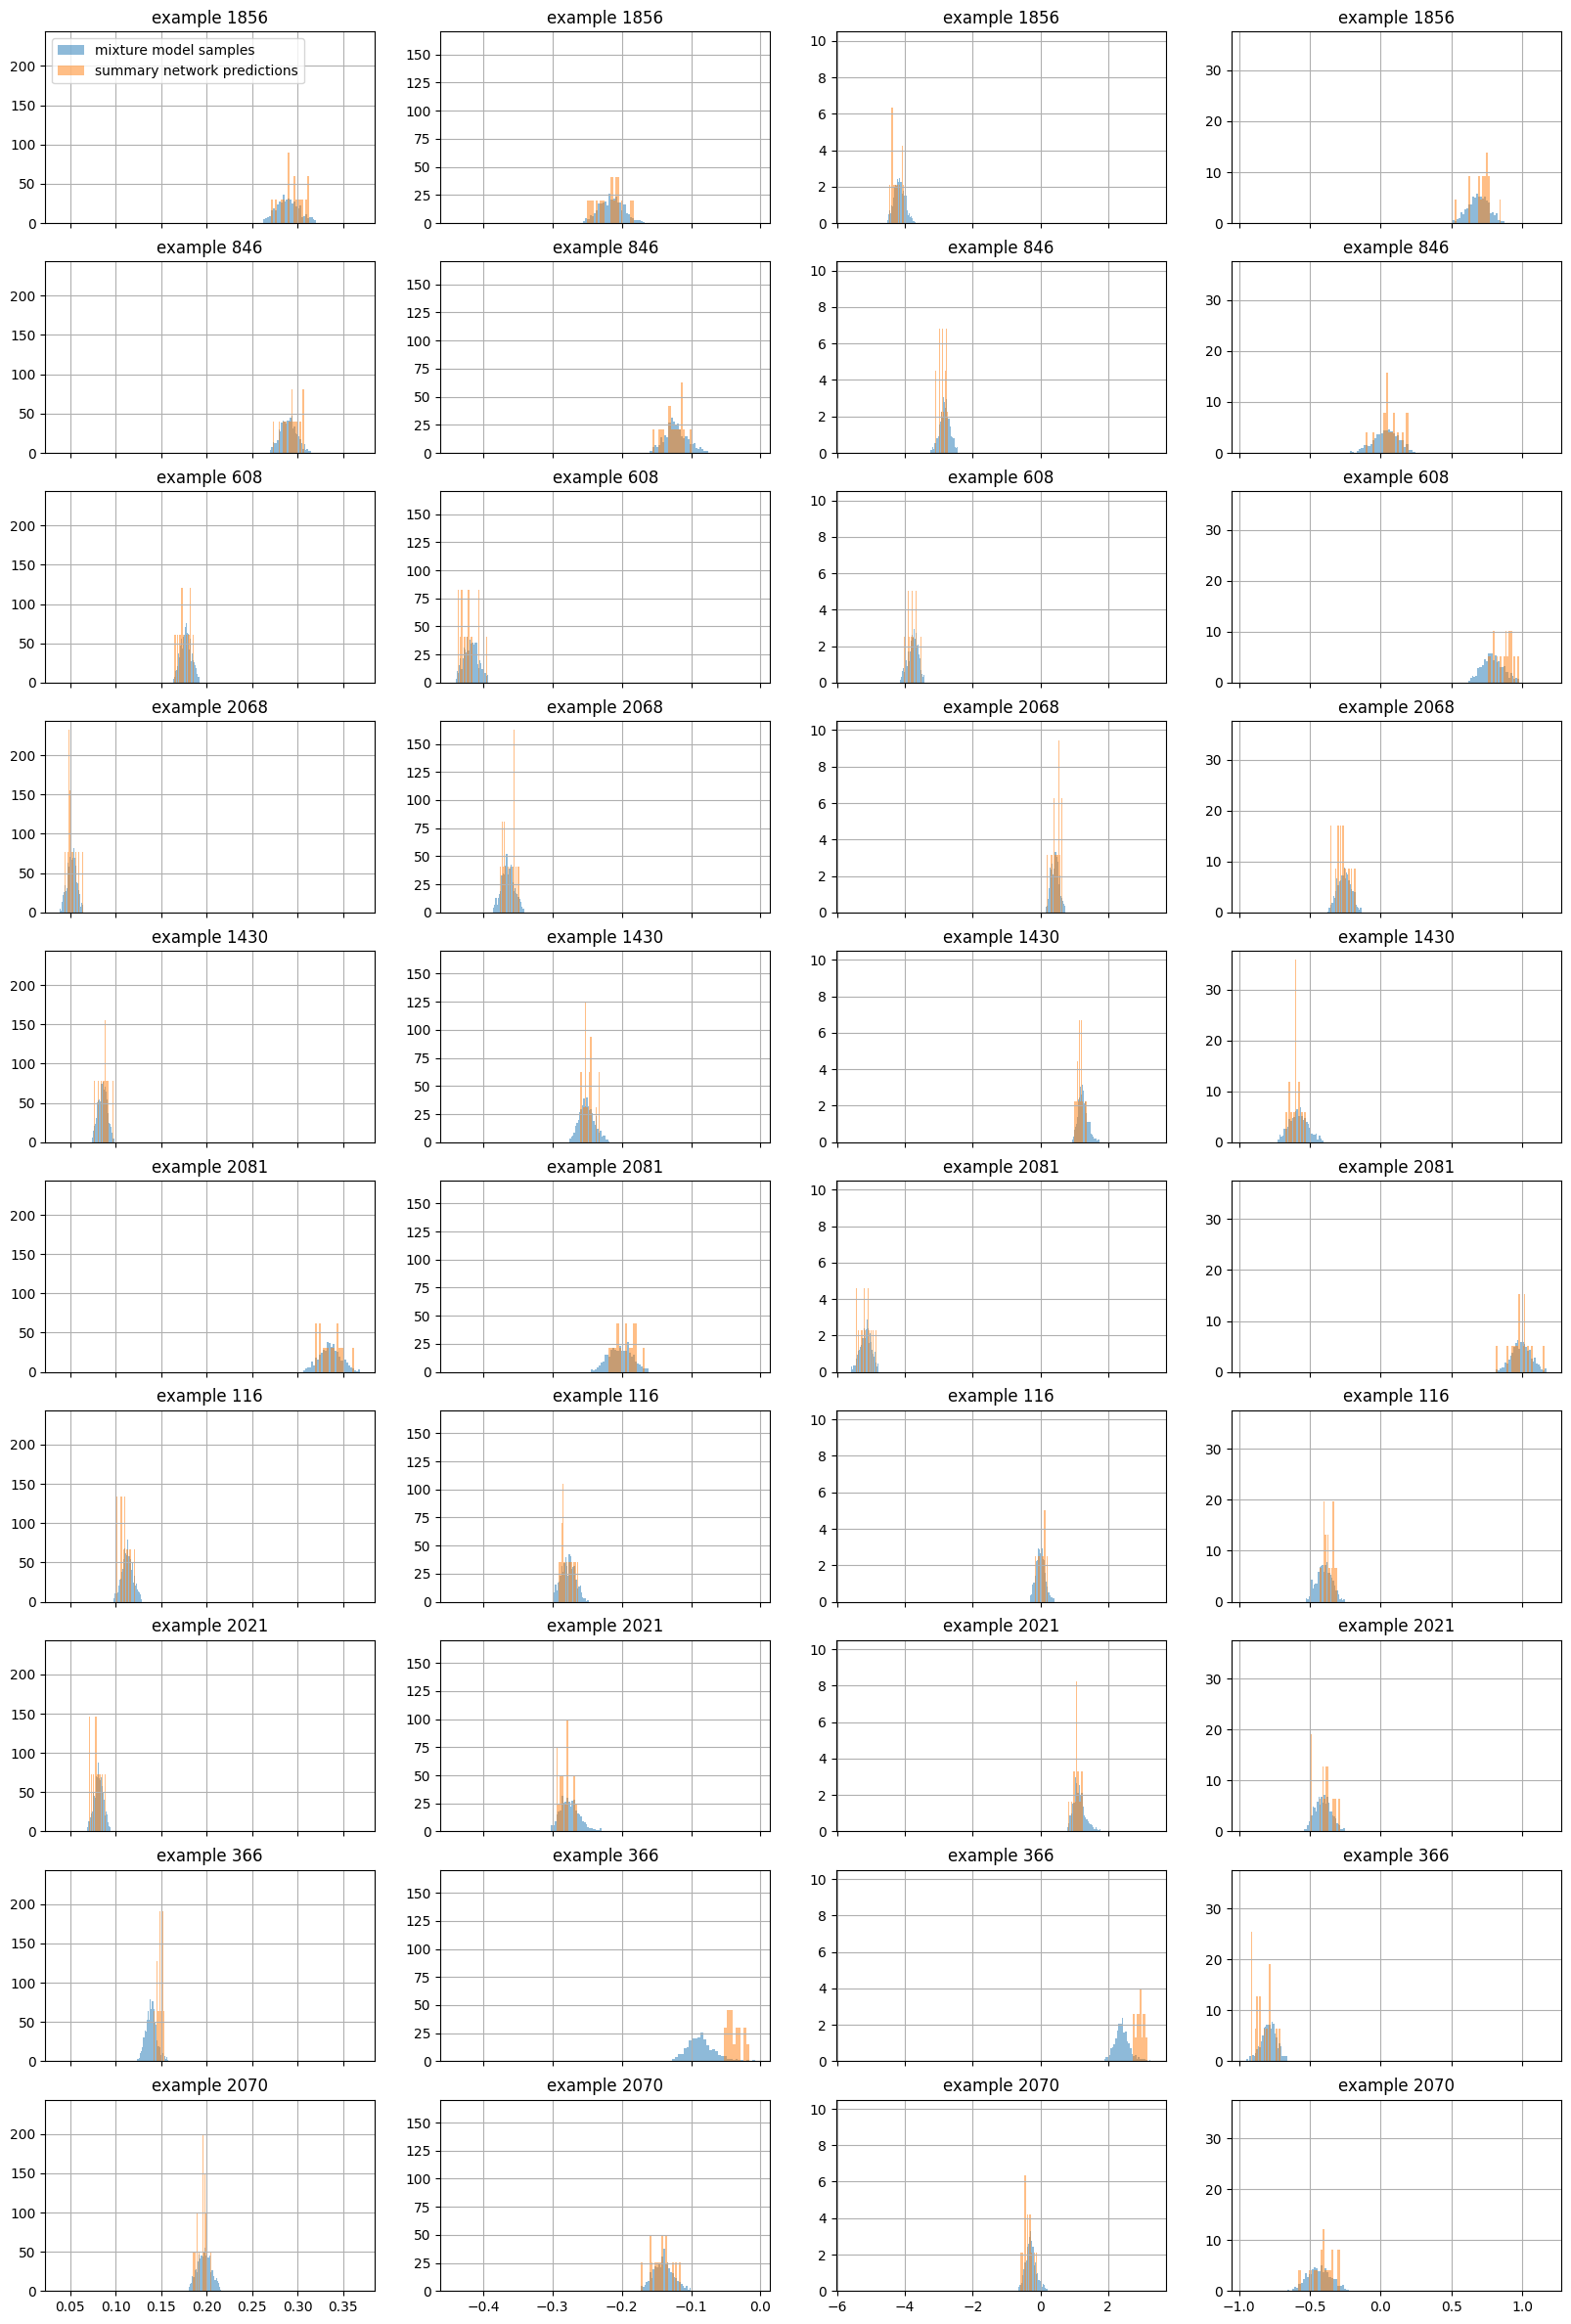

In [16]:
# random grid cosmologies
n_indices = 10
cosmo_indices = np.random.randint(0, n_cosmos, n_indices)

fig, ax = plt.subplots(figsize=(5*n_summaries, 3*n_indices), nrows=n_indices, ncols=n_summaries, sharex="col", sharey="col")

for i, i_cosmo in enumerate(cosmo_indices):
    for j in range(n_summaries):
        current_sample = pred_samples_array[i_cosmo,:,j]
        current_true = grid_preds[i_cosmo,:,j]
                        
        current_all = np.concatenate([current_sample, current_true]).ravel()
        current_min = np.quantile(current_all, 0.01)
        current_max = np.quantile(current_all, 0.99)
        current_bins = np.linspace(current_min, current_max, 30)

        ax[i,j].hist(current_sample, bins=current_bins, density=True, label="mixture model samples", alpha=0.5)
        ax[i,j].hist(current_true, bins=current_bins, density=True, label="summary network predictions", alpha=0.5)

        # cosmetics
        ax[i,j].set(title=f"example {i_cosmo}")
        ax[i,j].grid(True)
        
        if i==0 and j==0:
            ax[i,j].legend(loc="upper left")

### MCMC

In [17]:
def log_likelihood(X): 
    # convert to dataframe
    X = pd.DataFrame(X, columns=params)
    X = X.join(obs_df, how="cross")

    # evaluate the normalizing flow
    log_prob = flow.log_prob(X)
    
    # enforce the prior
    log_prob = prior.log_posterior(X.loc[:,params], log_prob, params=params, conf=None)

    return log_prob

In [18]:
chain = mcmc.run_emcee(
    log_likelihood,
    params,
    out_dir=out_dir,
    label=label,
    n_walkers=2048,
    n_steps=500,
)

23-07-21 03:35:10      mcmc.py INF   Initial values in prior: True 


100%|██████████| 500/500 [02:14<00:00,  3.71it/s]


### plot

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

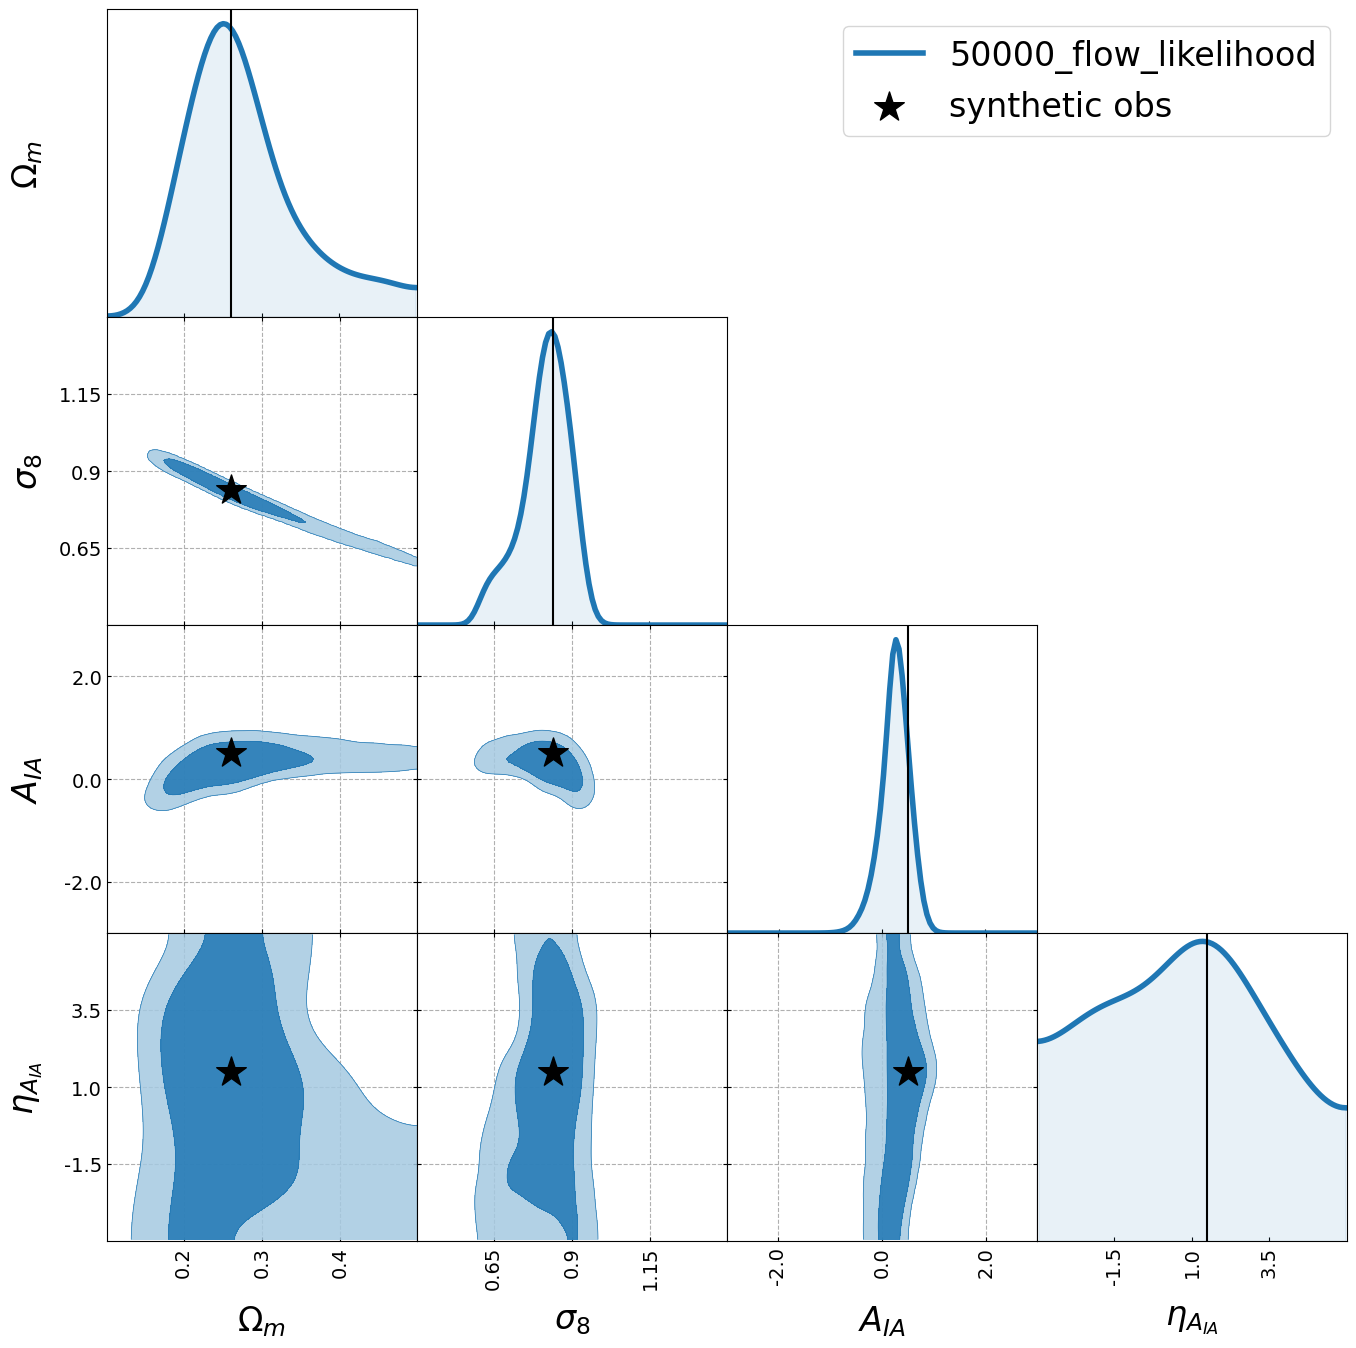

In [20]:
plotting.plot_chains(
    chain, 
    params, 
    out_dir=out_dir, 
    labels=label,
)

## learn the posterior $p(\theta | s)$

In [ ]:
label = f"{n_steps}_flow_posterior"

In [ ]:
latent = CentBeta13(input_dim=n_params, B=5)
bijector = Chain(
    ShiftBounds(jnp.array(df_total[params].min(axis=0)), jnp.array(df_total[params].max(axis=0)), B=4),
    RollingSplineCoupling(n_params, B=5, n_conditions=n_summaries, hidden_dim=128),
)

flow = Flow(
    data_columns=params, 
    conditional_columns=summary_labels, 
    latent=latent,
    bijector=bijector,
)

# train
loss_train, loss_val = flow.train(df_train, df_val, verbose=True, epochs=500, batch_size=2048)
# loss_train = flow.train(df_total, verbose=True, epochs=100)

# plot
fig, ax = plt.subplots()
ax.plot(loss_train, label="training set")
ax.plot(loss_val, label="validation set")
ax.set(xlabel="epoch", ylabel="loss")
ax.legend()
ax.grid(True)

### direct sampling

In [ ]:
%%time

# sample directly from the normalizing flow
samples = flow.sample(1000000, conditions=obs_df, save_conditions=False)

# check whether all of the parameter values are within the prior
assert list(samples.columns) == params
prior_mask = prior.in_grid_prior(samples, params=params)
samples = samples[prior_mask]

# convert to numpy and save
chain = samples.to_numpy()

if out_dir is not None:
    np.save(os.path.join(out_dir, f"chain_{label}.npy"), chain)

In [ ]:
plotting.plot_chain(
    chain, 
    params, 
    out_dir=out_dir, 
    label=label,
)